# Modal Rp1.500.000 — Portofolio V2 (rebalance antar coin) vs BTC Saja, dengan Order Minimum $5

**Keputusan user**: modal naik ke **Rp1.500.000** (≈ $92 pada kurs Rp16.300) supaya konsep portofolio
+ rebalance (V2, notebook 15) bisa dijalankan.

**Kendala nyata yang sekarang ikut disimulasikan**: order minimum Binance **$5 berlaku untuk setiap transaksi**,
termasuk penyesuaian kecil saat rebalance. Transaksi < $5 **dilewati** (posisi coin itu tidak berubah); coin yang
porsinya terlalu kecil untuk dibeli tetap cash; posisi < $5 tidak bisa dijual (tertahan sampai rebalance berikutnya).

| Kode | Strategi |
|---|---|
| V2-60 | 8 coin (BTC, ETH, BNB, XRP, ADA, LINK, TRX, DOGE ≤10%), inverse-vol, filter H8b, rebalance bulanan, porsi total 60% |
| V2-100 | sama, porsi total 100% |
| V2-60 tanpa DOGE | 7 coin, porsi 60% (DOGE paling sering < $5) |
| BTC-60 | strategi 13 (BTC saja), porsi 60% — pembanding |

Uji: kinerja penuh 2019–2026, **setiap awal bulan 2019-01 → 2025-06 sebagai tanggal mulai** (simulasi ulang
dari Rp1,5 juta, 12 bulan), dan Monte Carlo 10.000 jalur. Kill switch: modal ≤ **Rp1.050.000 (−30%)**.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index
from research.single_position import Panel, BTC
from research.portfolio import run_portfolio, inverse_vol_weights

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
MODAL, KURS, MIN_ORDER = 1_500_000, 16_300, 5.0
CAP_USD = MODAL / KURS
KILL = MODAL * 0.70
UNIV = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "LINKUSDT", "TRXUSDT", "DOGEUSDT"]
P = Panel({s: load_symbol(s, "1d", "since2018") for s in UNIV}, "2018-01-01", "2026-06-30")
fgi = load_fear_greed_index()["fng_value"].reindex(P.dates).ffill()
btc = P.close[BTC]
market = ((btc > btc.rolling(100, min_periods=100).mean()) | (fgi.rolling(14).mean() > 50)).astype(float)
v2 = inverse_vol_weights(P, UNIV, 60, {"DOGEUSDT": 0.10}).mul(market, axis=0)
no_doge = [s for s in UNIV if s != "DOGEUSDT"]
v2nd = inverse_vol_weights(P, no_doge, 60).mul(market, axis=0).reindex(columns=UNIV, fill_value=0.0)
b60 = pd.DataFrame(0.0, index=P.dates, columns=UNIV); b60[BTC] = market * 0.6
STRATS = {"V2-60": v2 * 0.6, "V2-100": v2, "V2-60 tanpa DOGE": v2nd * 0.6, "BTC-60": b60}
FULL = ("2019-01-01", "2026-06-30")
print(f"Modal Rp{MODAL:,} ≈ ${CAP_USD:.2f} | kill switch Rp{KILL:,.0f}")

Modal Rp1,500,000 ≈ $92.02 | kill switch Rp1,050,000


## 1. Ukuran order per coin & order yang dilewati

In [2]:
rows = []
for name, w in STRATS.items():
    held = w.loc[FULL[0]:FULL[1]]
    held = held[held.sum(axis=1) > 0]
    usd = (held * CAP_USD).replace(0, np.nan)
    _, info = run_portfolio(P, w, *FULL, capital_usd=CAP_USD, min_order_usd=MIN_ORDER)
    rows.append({"strategi": name, "coin dipegang": int((usd.notna()).any().sum()),
                 "order per coin rata2 ($)": round(usd.stack().mean(), 2),
                 "order terkecil rata2 per hari ($)": round(usd.min(axis=1).mean(), 2),
                 "% hari ada coin < $5": f"{(usd < MIN_ORDER).any(axis=1).mean():.0%}",
                 "transaksi dilewati (2019-2026)": info["order_dilewati"], "jumlah rebalance": info["n_rebalance"]})
pd.DataFrame(rows).set_index("strategi")

,coin dipegang,order per coin rata2 ($),order terkecil rata2 per hari ($),% hari ada coin < $5,transaksi dilewati (2019-2026),jumlah rebalance
strategi,,,,,,
V2-60,8,7.02,4.17,70%,193,158
V2-100,8,11.70,6.96,15%,100,158
V2-60 tanpa DOGE,7,7.91,4.99,51%,166,157
BTC-60,1,55.21,55.21,0%,19,156


## 2. Kinerja penuh 2019-01 → 2026-06 (mulai Rp1,5 juta, order minimum $5)

In [3]:
def stats(eq):
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    tot = eq.iloc[-1] / eq.iloc[0] - 1
    mon = eq.resample("ME").last().pct_change().dropna()
    yr = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
    dr = eq.pct_change().dropna()
    return {"profit/tahun": (1 + tot) ** (1 / yrs) - 1, "max drawdown": (eq / eq.cummax() - 1).min(),
            "sharpe": dr.mean() / dr.std() * np.sqrt(365), "tahun terburuk": yr.min(),
            "% bulan untung": (mon > 0).mean(), "rata2 profit/bulan (Rp, modal tetap)": mon.mean() * MODAL,
            "bulan terburuk (Rp)": mon.min() * MODAL}
curves = {name: run_portfolio(P, w, *FULL, capital_usd=CAP_USD, min_order_usd=MIN_ORDER)[0] for name, w in STRATS.items()}
T = pd.DataFrame({n: stats(e) for n, e in curves.items()})
out = T.copy().astype(object)
for i in T.index:
    out.loc[i] = T.loc[i].map(lambda v: f"{v:.2f}" if i == "sharpe" else (f"Rp{v:,.0f}" if "Rp" in i else f"{v:+.1%}" if "%" not in i else f"{v:.0%}"))
out

,V2-60,V2-100,V2-60 tanpa DOGE,BTC-60
profit/tahun,+69.4%,+113.0%,+60.5%,+36.3%
max drawdown,-26.4%,-44.0%,-26.4%,-24.4%
sharpe,1.58,1.60,1.57,1.23
tahun terburuk,-10.4%,-17.4%,-10.9%,-12.9%
% bulan untung,45%,45%,43%,42%
"rata2 profit/bulan (Rp, modal tetap)","Rp82,703","Rp133,758","Rp71,915","Rp45,512"
bulan terburuk (Rp),"Rp-223,150","Rp-365,196","Rp-212,016","Rp-230,917"


In [4]:
yr = pd.DataFrame({n: e.groupby(e.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1) for n, e in curves.items()}).T
yr.columns = [f"{y}{' (-Jun)' if y == 2026 else ''}" for y in yr.columns]
yr.map(lambda v: f"{v:+.0%}")

,2019,2020,2021,2022,2023,2024,2025,2026 (-Jun)
V2-60,+50%,+116%,+582%,-10%,+42%,+72%,+4%,-2%
V2-100,+62%,+234%,+1447%,-17%,+72%,+122%,+5%,-4%
V2-60 tanpa DOGE,+50%,+126%,+347%,-11%,+45%,+63%,+7%,-3%
BTC-60,+74%,+99%,+45%,-13%,+52%,+52%,+1%,-5%


### 2b. Tanpa pengaruh bull 2021: periode uji 2023-01 → 2026-06 saja (mulai Rp1,5 juta)

Tahun 2021 (bull altcoin) membuat rata-rata periode penuh terlihat sangat tinggi. Periode 2023–2026 adalah
periode uji yang tidak dipakai saat memilih strategi (notebook 15).

In [5]:
rows = {}
for name, w in STRATS.items():
    eq, _ = run_portfolio(P, w, "2023-01-01", "2026-06-30", capital_usd=CAP_USD, min_order_usd=MIN_ORDER)
    mon = eq.resample("ME").last().pct_change().dropna()
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    rows[name] = {"nilai akhir (mulai Rp1,5 jt)": eq.iloc[-1] * MODAL,
                  "profit/tahun": (eq.iloc[-1]) ** (1 / yrs) - 1,
                  "max drawdown": (eq / eq.cummax() - 1).min(),
                  "rata2 profit/bulan (Rp)": mon.mean() * MODAL,
                  "median profit/bulan (Rp)": mon.median() * MODAL,
                  "% bulan untung": (mon > 0).mean(),
                  "bulan terburuk (Rp)": mon.min() * MODAL}
T2 = pd.DataFrame(rows)
out = T2.copy().astype(object)
for i in T2.index:
    out.loc[i] = T2.loc[i].map(lambda v: f"Rp{v:,.0f}" if ("Rp" in i or "nilai" in i) else (f"{v:.0%}" if i.startswith("%") else f"{v:+.1%}"))
out

,V2-60,V2-100,V2-60 tanpa DOGE,BTC-60
"nilai akhir (mulai Rp1,5 jt)","Rp3,776,236","Rp5,852,819","Rp3,904,139","Rp3,441,273"
profit/tahun,+30.2%,+47.7%,+31.5%,+26.8%
max drawdown,-19.2%,-33.8%,-21.7%,-20.2%
rata2 profit/bulan (Rp),"Rp36,914","Rp59,852","Rp37,723","Rp28,232"
median profit/bulan (Rp),Rp0,Rp0,Rp0,Rp0
% bulan untung,44%,46%,41%,46%
bulan terburuk (Rp),"Rp-138,342","Rp-262,245","Rp-131,140","Rp-134,021"


## 3. Setiap awal bulan sebagai tanggal mulai (simulasi ulang dari Rp1,5 juta, 12 bulan)

In [6]:
starts = pd.date_range("2019-01-01", "2025-06-01", freq="MS")
res = {}
for name, w in STRATS.items():
    rows = []
    for t0 in starts:
        t1 = t0 + pd.DateOffset(months=12) - pd.Timedelta(days=1)
        eq, _ = run_portfolio(P, w, str(t0.date()), str(t1.date()), capital_usd=CAP_USD, min_order_usd=MIN_ORDER)
        path = eq / eq.iloc[0] * MODAL
        rows.append(dict(mulai=t0, b1=path.loc[:t0 + pd.DateOffset(months=1)].iloc[-1],
                         b6=path.loc[:t0 + pd.DateOffset(months=6)].iloc[-1], b12=path.iloc[-1], low=path.min()))
    res[name] = pd.DataFrame(rows).set_index("mulai")
summary = {}
for name, r in res.items():
    summary[name] = {"jumlah tanggal mulai": len(r),
                     "% >= modal setelah 1 bulan": (r.b1 >= MODAL).mean(),
                     "% >= modal setelah 6 bulan": (r.b6 >= MODAL).mean(),
                     "% >= modal setelah 12 bulan": (r.b12 >= MODAL).mean(),
                     "median nilai 12 bulan": r.b12.median(),
                     "nilai 12 bulan terburuk": r.b12.min(),
                     "titik terendah (median)": r.low.median(),
                     "titik terendah (terburuk)": r.low.min(),
                     "% pernah < Rp1,2 jt (-20%)": (r.low < MODAL * 0.8).mean(),
                     "% sentuh kill switch Rp1,05 jt": (r.low <= KILL).mean()}
S = pd.DataFrame(summary)
out = S.copy().astype(object)
for i in S.index:
    out.loc[i] = S.loc[i].map(lambda v: f"{int(v)}" if i.startswith("jumlah") else (f"{v:.0%}" if i.startswith("%") else f"Rp{v:,.0f}"))
out

,V2-60,V2-100,V2-60 tanpa DOGE,BTC-60
jumlah tanggal mulai,78,78,78,78
% >= modal setelah 1 bulan,63%,64%,63%,60%
% >= modal setelah 6 bulan,74%,76%,78%,73%
% >= modal setelah 12 bulan,91%,88%,88%,85%
median nilai 12 bulan,"Rp2,126,996","Rp2,526,946","Rp2,115,920","Rp1,948,703"
nilai 12 bulan terburuk,"Rp1,194,209","Rp1,095,400","Rp1,227,804","Rp1,230,571"
titik terendah (median),"Rp1,435,876","Rp1,375,823","Rp1,440,310","Rp1,403,906"
titik terendah (terburuk),"Rp1,134,960","Rp910,858","Rp1,150,956","Rp1,182,823"
"% pernah < Rp1,2 jt (-20%)",5%,14%,1%,3%
"% sentuh kill switch Rp1,05 jt",0%,3%,0%,0%


## 4. Monte Carlo 10.000 jalur × 12 bulan (block bootstrap 30 hari dari return harian 2019–2026)

In [7]:
def monte_carlo(eq, n_paths=10_000, horizon=365, block=30, seed=7):
    r = eq.pct_change().dropna().to_numpy()
    rng = np.random.default_rng(seed)
    starts_ = rng.integers(0, len(r) - block, size=(n_paths, int(np.ceil(horizon / block))))
    paths = r[starts_[:, :, None] + np.arange(block)].reshape(n_paths, -1)[:, :horizon]
    return MODAL * np.cumprod(1 + paths, axis=1)

mc = {}
for name, eq in curves.items():
    v = monte_carlo(eq); end, low = v[:, -1], v.min(axis=1)
    mc[name] = {"% jalur untung 12 bulan": (end > MODAL).mean(), "median nilai 12 bulan": np.median(end),
                "5% terburuk nilai 12 bulan": np.percentile(end, 5), "median titik terendah": np.median(low),
                "% sentuh kill switch Rp1,05 jt": (low <= KILL).mean()}
M = pd.DataFrame(mc)
out = M.copy().astype(object)
for i in M.index:
    out.loc[i] = M.loc[i].map(lambda v: f"{v:.1%}" if i.startswith("%") else f"Rp{v:,.0f}")
out

,V2-60,V2-100,V2-60 tanpa DOGE,BTC-60
% jalur untung 12 bulan,90.3%,88.4%,90.5%,85.3%
median nilai 12 bulan,"Rp2,395,982","Rp2,963,212","Rp2,317,900","Rp2,011,149"
5% terburuk nilai 12 bulan,"Rp1,353,285","Rp1,201,988","Rp1,364,390","Rp1,289,534"
median titik terendah,"Rp1,411,268","Rp1,346,418","Rp1,414,079","Rp1,396,854"
"% sentuh kill switch Rp1,05 jt",1.6%,12.5%,1.4%,1.8%


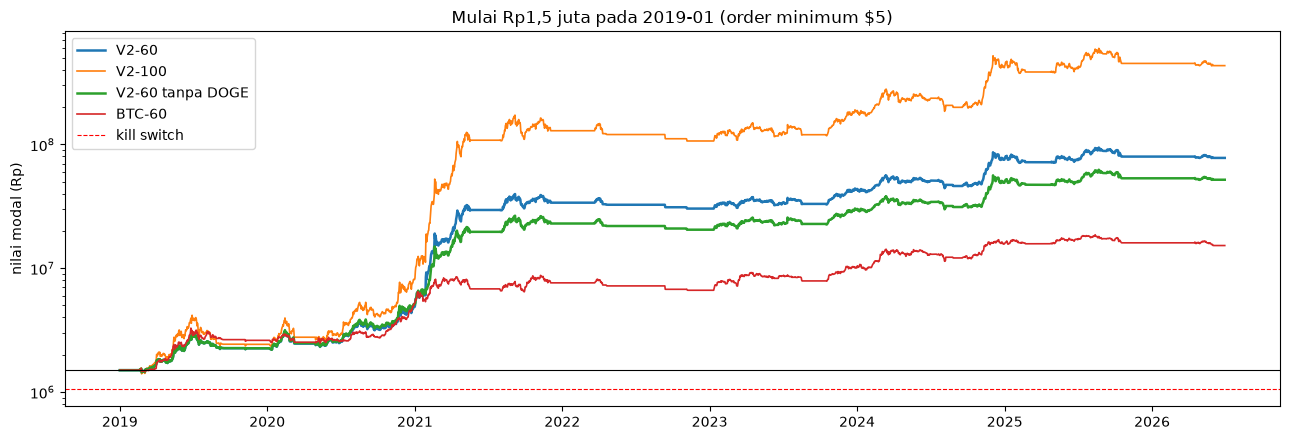

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.5))
for name, e in curves.items():
    ax.plot(e.index, e / e.iloc[0] * MODAL, lw=1.8 if name.startswith("V2-60") else 1.2, label=name)
ax.axhline(MODAL, color="black", lw=0.8); ax.axhline(KILL, color="red", ls="--", lw=0.8, label="kill switch")
ax.set_yscale("log"); ax.set_ylabel("nilai modal (Rp)"); ax.set_title("Mulai Rp1,5 juta pada 2019-01 (order minimum $5)")
ax.legend(); plt.tight_layout(); plt.show()

## Kesimpulan

### 1. Dengan Rp1,5 juta, portofolio V2 **bisa dijalankan** — tapi mepet
- V2-60: order rata-rata **$7 per coin**; 70% hari ada coin (biasanya DOGE/LINK) di bawah $5 → 193 transaksi
  kecil dilewati selama 2019–2026. Strategi tetap berjalan (penyesuaian kecil saja yang dilewati).
- V2-100 lebih longgar (order ±$11.7, hanya 15% hari ada coin < $5) tapi drawdown jauh lebih besar.

### 2. Hasil realistis — periode uji 2023-01 → 2026-06 (tanpa pengaruh bull 2021)
| Mulai Rp1,5 juta | **V2-60** | V2-100 | V2-60 tanpa DOGE | BTC-60 |
|---|---|---|---|---|
| Nilai akhir (3,5 tahun) | **Rp3,78 jt** | Rp5,85 jt | Rp3,90 jt | Rp3,44 jt |
| Profit/tahun | **+30%** | +48% | +32% | +27% |
| Max drawdown | **−19%** | −34% | −22% | −20% |
| Rata-rata profit/bulan | **±Rp37rb** (±Rp1.200/hari) | ±Rp60rb | ±Rp38rb | ±Rp28rb |
| % bulan untung | 44% | 46% | 41% | 46% |
| Bulan terburuk | −Rp138rb | −Rp262rb | −Rp131rb | −Rp134rb |

Median profit per bulan **Rp0**: sekitar setengah bulan dihabiskan di cash (filter pasar mati) atau rugi kecil —
keuntungan datang dari beberapa bulan tren naik. Periode penuh 2019–2026 terlihat jauh lebih tinggi
(V2-60 +69%/tahun) **karena bull altcoin 2021 (+582%)** — jangan dijadikan patokan.

### 3. Ketahanan modal (setiap awal bulan 2019–2025 sebagai tanggal mulai, 12 bulan)
| | **V2-60** | V2-100 | BTC-60 |
|---|---|---|---|
| % modal ≥ Rp1,5 jt setelah 12 bulan | **91%** | 88% | 85% |
| Median nilai 12 bulan | Rp2,13 jt | Rp2,53 jt | Rp1,95 jt |
| Titik terendah terburuk | **Rp1,13 jt** (−24%) | Rp0,91 jt (−39%) | Rp1,18 jt |
| Sentuh kill switch Rp1,05 jt | **0%** (Monte Carlo 1.6%) | 3% (MC 12.5%) | 0% (MC 1.8%) |

**Tidak ada margin call** (spot tanpa leverage). Satu dari tiga bulan bisa berakhir di bawah modal, tapi dalam
12 bulan ±9 dari 10 kemungkinan modal bertambah.

### Rekomendasi untuk modal Rp1,5 juta: **V2-60**
- 8 coin (BTC, ETH, BNB, XRP, ADA, LINK, TRX, DOGE ≤10%), porsi inverse-volatilitas, **porsi total 60%**
  (40% tetap stablecoin), filter pasar H8b, rebalance tanggal 1 + saat filter berubah, **lewati order < $5**.
- Ekspektasi: ±+30%/tahun, rata-rata ±Rp37rb/bulan (tidak rata — banyak bulan Rp0), drawdown ±20–24%.
- Kill switch: modal ≤ **Rp1.050.000** → bot berhenti & evaluasi.
- Catatan: dengan modal ini DOGE sering tidak bisa dibeli (< $5); versi tanpa DOGE hasilnya hampir sama.